<img src=img/itq.jpg>

![logo](img/python.jpg)

Geovanny Nazareno

## **NUESTRA PRIMERA RED NEURONAL: MNIST DATASET**

In [ ]:
!pip install $packageName

In [ ]:
!pip freeze

Hola voy a ejecutar el comando ```!pip freeze``` para cotillear a Google Colab

In [ ]:
!nvidia-smi

In [1]:
#Importemos TensorFlow 2.X y Numpy
import numpy as np
import tensorflow as tf
tf.__version__

'2.21.0'

#### **- Cargando el conjunto de datos**

In [2]:
# Importamos el dataset MNIST y cargamos los datos
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


#### **- Inspeccionando el conjunto de datos**

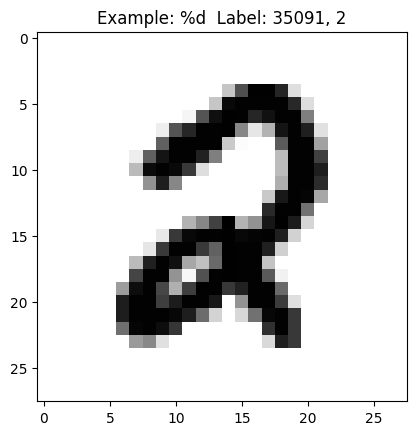

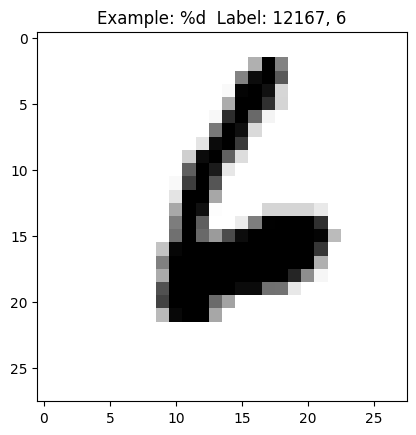

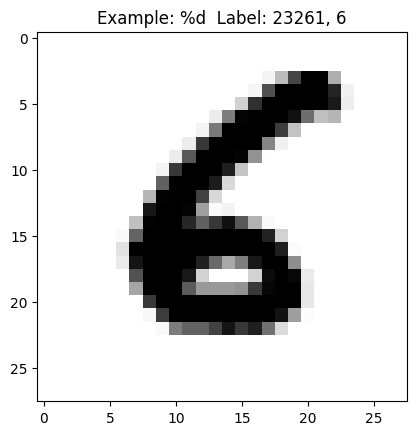

In [3]:
import matplotlib.pyplot as plt
# Función auxiliar para visualizar datos de entrenamiento de manera aleatoria
def display_digit(num,x_train,y_train):
  # Seleccionar la imagen num de mnist.train.images y hacer un reshape al tamaño de la imagen
  image = x_train[num,:,:]
  # Seleccionar el target num de mnist.train.labels
  label = y_train[num]
  # Mostrar
  plt.title(f'Example: %d  Label: {num}, {label}')
  plt.imshow(image, cmap=plt.get_cmap('gray_r'))
  plt.show()

# Mostramos algunos ejemplos
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)
display_digit(np.random.randint(0, x_train.shape[0]),x_train,y_train)

In [4]:
np.random.randint(0, x_train.shape[0])

33566

#### **- Acondicionando el conjunto de datos**

In [5]:
# Pre-procesado obligatorio cuando trabajo con redes neuronales
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

x_train, x_te = x_train / 255.0, x_test / 255.0 #Cambio al rango 0-1 -> Disminuyo CC
y_train = to_categorical(y_train, num_classes=10) #One-hot encoding para minimizar error
print(y_train.shape)
y_te = to_categorical(y_test, num_classes=10)
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42) # 3 subconjuntos es de vital importancia
print(y_tr.shape)
# print(y_tr[0])

(60000, 10)
(54000, 10)


In [6]:
print(y_tr[5214])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [7]:
print(y_tr[5214].argmax(axis=0))

4


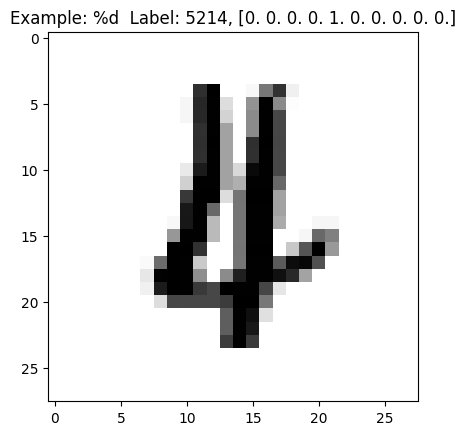

In [8]:
display_digit(5214, x_tr,y_tr)

#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [9]:
# Voy a necesitar importar una serie de modulos para programar mi red neuronal
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
# Vamos a codificar la topología de nuestra primera red neuronal!!!
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(512, input_shape=(28*28,), activation="relu"))
model.add(Dense(10, activation="softmax")) #Capa salida -> Mismo número de neuronas que de clases objetivo

# Ahí tenemos nuestro primer MLP con una única capa oculta de 512 neuronas

C:\Users\HP\anaconda3\envs\maching\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
C:\Users\HP\anaconda3\envs\maching\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
#Traigamos nuestro optimizador
from tensorflow.keras.optimizers import SGD
# Ahora que tengo definida la arquitectura, la compilo
model.compile(loss="categorical_crossentropy", optimizer=SGD(0.005), metrics=["accuracy"])

In [11]:
######### Modelo funcional ############ (Clase 04/10/2023)
# Definir la entrada
input_layer = Input(shape=(28, 28))
# Capa de aplanamiento
x = Flatten()(input_layer)
x = Dense(512, activation="relu")(x)
# x= Dropout(0.5)(x) Introducción de capa de dropout en un modelo funcional
output_layer = Dense(10, activation="softmax")(x)
# Crear el modelo
model = Model(inputs=input_layer, outputs=output_layer)

In [12]:
print(model.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

None


In [13]:
# Ahora que tengo definida la arquitectura, la compilo
model.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase/ para regresion (mse/mae)
               metrics=['accuracy'])

In [14]:
# Por fin podemos entrenar nuestra primera red neuronal
print("[INFO]: Entrenando red neuronal...")
H = model.fit(x_tr, y_tr, validation_data=(x_val, y_val), epochs=50, batch_size=128)

[INFO]: Entrenando red neuronal...
Epoch 1/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9201 - loss: 0.2817 - val_accuracy: 0.9602 - val_loss: 0.1424
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9671 - loss: 0.1153 - val_accuracy: 0.9740 - val_loss: 0.0953
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9782 - loss: 0.0744 - val_accuracy: 0.9753 - val_loss: 0.0820
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9837 - loss: 0.0547 - val_accuracy: 0.9790 - val_loss: 0.0700
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9879 - loss: 0.0406 - val_accuracy: 0.9810 - val_loss: 0.0629
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9922 - loss: 0.0288 - val_accuracy: 0.9827 - val_loss: 0.0617
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9941 - loss: 0.0224 - val_accuracy: 0.9815 - val_loss: 0.0633
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accurac

#### **Mecanismo para predecir el numero que se muestra en la imagen**

In [15]:
from tensorflow.keras.models import load_model
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(182.5), np.float64(182.5), np.float64(-0.5))

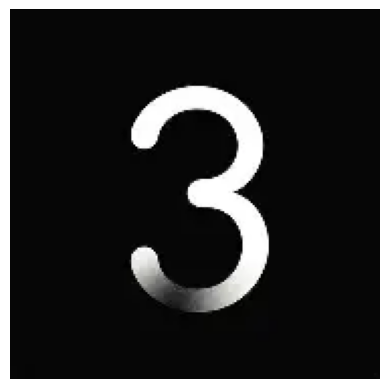

In [16]:
# cargar imagen
img = Image.open("3.jpg")

# mostrar imagen
plt.imshow(img)
plt.axis("off")

In [17]:
# Convierto la imagen 
img = img.convert('L')
img = img.resize((28,28))

img_array = np.array(img)/255.0
img_array = img_array.reshape(1,28,28,1)

In [18]:
# Meodo para predecir el numero de la imagen 
pred = model.predict(img_array)

numero = np.argmax(pred)

print("Número predicho:", numero)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Número predicho: 3


#### **- Observando el proceso de entrenamiento para tomar decisiones**

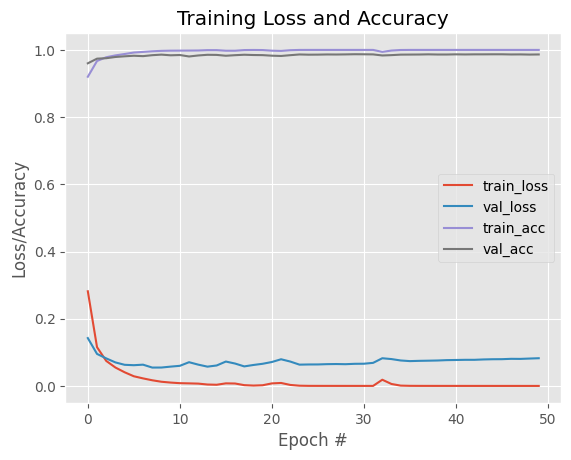

In [19]:
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 50), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 50), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 50), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 50), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [ ]:
from sklearn.metrics import classification_report
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
predictions = model.predict(x_te, batch_size=128)
print(y_te[0])
print(predictions[0])
print(classification_report(y_te.argmax(axis=1), predictions.argmax(axis=1)))

In [ ]:
predictions[0].argmax(axis=0)

In [ ]:
y_te[0].argmax(axis=0)

In [ ]:
print(model.summary())

--------------------------------------------------------------------------

## **MLP APLICADO A TEXTO: EJEMPLO REUTERS**

#### **- Cargando el conjunto de datos**

In [20]:
import numpy as np
import tensorflow as tf
# Importamos el dataset REUTERS y cargamos los datos
reuters = tf.keras.datasets.reuters
WORD_LIMIT = 10000
(training_data, training_labels), (testing_data, testing_labels) = reuters.load_data(num_words=WORD_LIMIT)
print(training_data.shape)
print(training_labels.shape)
print(testing_data.shape)
print(testing_labels.shape)

C:\Users\HP\anaconda3\envs\maching\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


(8982,)
(8982,)
(2246,)
(2246,)


#### **- Inspeccionando el conjunto de datos**

In [21]:
# Los datos son numericos para decodificarlos, se puede usar reuters.get_word_index()
word_index = reuters.get_word_index()
reverse_word_index = dict({value : key for key, value in word_index.items()})
decoded = ' '.join(
    [reverse_word_index.get(i-3,'?') for i in training_data[5]]
)
decoded

"? the u s agriculture department estimated canada's 1986 87 wheat crop at 31 85 mln tonnes vs 31 85 mln tonnes last month it estimated 1985 86 output at 24 25 mln tonnes vs 24 25 mln last month canadian 1986 87 coarse grain production is projected at 27 62 mln tonnes vs 27 62 mln tonnes last month production in 1985 86 is estimated at 24 95 mln tonnes vs 24 95 mln last month canadian wheat exports in 1986 87 are forecast at 19 00 mln tonnes vs 18 00 mln tonnes last month exports in 1985 86 are estimated at 17 71 mln tonnes vs 17 72 mln last month reuter 3"

#### **- Acondicionando el conjunto de datos**

In [22]:
# Función auxiliar para representar las palabras (que no entiende nuestra red neuronal) en números
import numpy as np
# one hot encoding del input, vector con cada indice indicando si una palabra esta presente
def one_hot_encode(data):
    encoded = np.zeros((len(data),WORD_LIMIT))
    for i, v in enumerate(data):
        encoded[i,v] = 1 # localiza las columnas del genero correspondiente, marca con 1
    return encoded

In [23]:
# Convertimos nuestras palabras a números
x_train = one_hot_encode(training_data)
x_test = one_hot_encode(testing_data)
print(x_train.shape)
print(x_test.shape)

(8982, 10000)
(2246, 10000)


In [24]:
print(x_test[3])

[0. 1. 1. ... 0. 0. 0.]


In [25]:
# Convertimos nuestros labels (categoría reseña) a one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(training_labels)
y_test = to_categorical(testing_labels)
print(y_train.shape)
print(y_test.shape)

(8982, 46)
(2246, 46)


In [26]:
print(y_test[3])

[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


#### **- Creando la topología de Red Neuronal (MLP) y entrenándola**

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Vamos a codificar la topología de nuestro MLP
model = Sequential()
model.add(Dense(128,activation='relu',input_shape=(WORD_LIMIT,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes
# En el caso de regresión cambiamos la ultima capa por:
#model.add(Dense(1,activation='sigmoid'))

C:\Users\HP\anaconda3\envs\maching\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
# Ahora que tengo definida la arquitectura, la compilo
model.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase/ para regresion (mse/mae)
               metrics=['accuracy'])

In [29]:
# A entrenar nuestra red neuronal sea dicho!
H = model.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6960 - loss: 1.4651 - val_accuracy: 0.7924 - val_loss: 0.9819
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.8811 - loss: 0.5567 - val_accuracy: 0.8108 - val_loss: 0.8687
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9400 - loss: 0.2722 - val_accuracy: 0.8091 - val_loss: 0.9099
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9549 - loss: 0.1907 - val_accuracy: 0.8002 - val_loss: 0.9774
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9587 - loss: 0.1524 - val_accuracy: 0.7941 - val_loss: 0.9656
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9596 - loss: 0.1371 - val_accuracy: 0.8024 - val_loss: 0.9537
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9596 - loss: 0.1245 - val_accuracy: 0.7980 - val_loss: 0.9991
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9587 - loss: 0.1218 - val_accu

#### **- Observando el proceso de entrenamiento para tomar decisiones**

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 128)                 │       1,280,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 46)                  │           2,990 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,291,374 (4.93 MB)

 Trainable params: 1,291,374 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

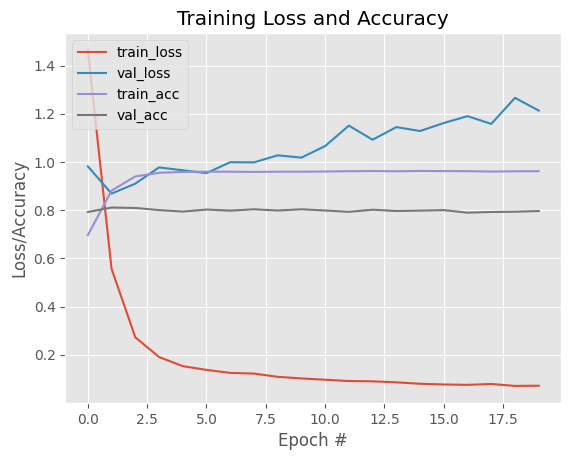

In [32]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

#### **- Probando el conjunto de datos en el subset de test y evaluando el performance del modelo**

In [33]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model.predict(x_test)
loss, accuracy = model.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7916 - loss: 1.2970
Loss 1.2969882488250732, accuracy 0.7916295528411865


## **REGULARIZACIÓN EN APRENDIZAJE PROFUNDO**

#### **- Weight regularization L1/L2**

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers
# Vamos a codificar la topología de nuestro MLP
model_reg = Sequential()
model_reg.add(Dense(128,activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(WORD_LIMIT,)))
model_reg.add(Dense(64,activation='relu', kernel_regularizer=regularizers.l2(0.01)))
model_reg.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\HP\anaconda3\envs\maching\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# Ahora que tengo definida la arquitectura, la compilo
model_reg.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [36]:
# A entrenar nuestra red neuronal sea dicho!
H = model_reg.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6374 - loss: 2.3904 - val_accuracy: 0.7262 - val_loss: 1.8004
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7294 - loss: 1.6891 - val_accuracy: 0.7373 - val_loss: 1.6608
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7511 - loss: 1.5899 - val_accuracy: 0.7418 - val_loss: 1.6172
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7610 - loss: 1.5424 - val_accuracy: 0.7457 - val_loss: 1.5933
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7642 - loss: 1.4999 - val_accuracy: 0.7551 - val_loss: 1.5909
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7731 - loss: 1.4690 - val_accuracy: 0.7485 - val_loss: 1.5693
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7749 - loss: 1.4509 - val_accuracy: 0.7446 - val_loss: 1.5807
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7809 - loss: 1.4223 - val_accu

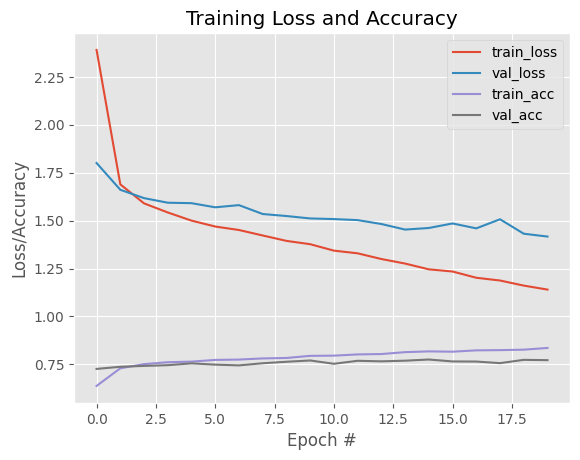

In [37]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [38]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_reg.predict(x_test)
loss, accuracy = model_reg.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7596 - loss: 1.4550
Loss 1.4549586772918701, accuracy 0.7595725655555725


#### **- Dropout**

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
# Vamos a codificar la topología de nuestro MLP
model_drop = Sequential()
model_drop.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(64,activation='relu'))
#model_drop.add(Dropout(0.5))
model_drop.add(Dropout(0.55))
model_drop.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\HP\anaconda3\envs\maching\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
# Ahora que tengo definida la arquitectura, la compilo
model_drop.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [41]:
# A entrenar nuestra red neuronal sea dicho!
H = model_drop.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5283 - loss: 1.9964 - val_accuracy: 0.6995 - val_loss: 1.3548
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.6754 - loss: 1.3718 - val_accuracy: 0.7323 - val_loss: 1.1706
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7237 - loss: 1.1433 - val_accuracy: 0.7618 - val_loss: 1.0797
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.7588 - loss: 0.9764 - val_accuracy: 0.7707 - val_loss: 1.0373
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7876 - loss: 0.8602 - val_accuracy: 0.7819 - val_loss: 1.0110
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8074 - loss: 0.7661 - val_accuracy: 0.7902 - val_loss: 1.0247
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8200 - loss: 0.6990 - val_accuracy: 0.7941 - val_loss: 1.0241
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8294 - loss: 0.6502 - val_acc

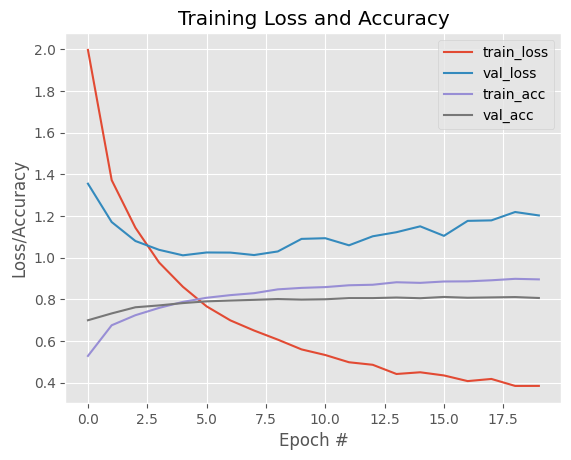

In [42]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

# ¿Y si desconectamos mayor porcentaje de neuronas?

In [43]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_drop.predict(x_test)
loss, accuracy = model_drop.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7983 - loss: 1.3479
Loss 1.3478566408157349, accuracy 0.7983080744743347


#### **- Batch Normalization**

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
# Vamos a codificar la topología de nuestro MLP
model_bn = Sequential()
model_bn.add(Dense(128,activation='relu', input_shape=(WORD_LIMIT,)))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(64,activation='relu'))
model_bn.add(BatchNormalization())
model_bn.add(Dropout(0.6))
model_bn.add(Dense(46,activation='softmax')) # Reparto de la unidad de probabilidad entre num_classes

C:\Users\HP\anaconda3\envs\maching\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
# Ahora que tengo definida la arquitectura, la compilo
model_bn.compile(optimizer='adam',
               loss='categorical_crossentropy', # ideal para clasificacion multiclase
               metrics=['accuracy'])

In [46]:
# A entrenar nuestra red neuronal sea dicho!
H = model_bn.fit(x_train,y_train,epochs=20,batch_size=32, validation_split=0.2)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.4774 - loss: 2.5376 - val_accuracy: 0.6995 - val_loss: 1.6066
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6697 - loss: 1.5290 - val_accuracy: 0.7340 - val_loss: 1.2068
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7169 - loss: 1.2896 - val_accuracy: 0.7668 - val_loss: 1.1103
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.7481 - loss: 1.0889 - val_accuracy: 0.7802 - val_loss: 1.0527
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.7692 - loss: 0.9798 - val_accuracy: 0.7858 - val_loss: 1.0083
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7974 - loss: 0.8538 - val_accuracy: 0.7885 - val_loss: 0.9888
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8120 - loss: 0.7690 - val_accuracy: 0.7924 - val_loss: 0.9698
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8260 - loss: 0.7083 - val_accu

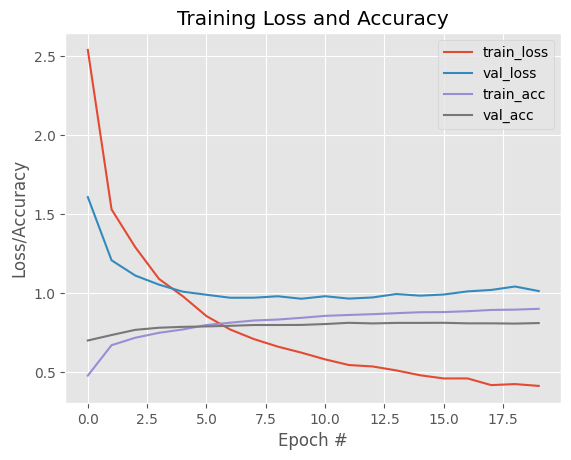

In [47]:
import matplotlib.pyplot as plt
# Muestro gráfica de accuracy y losses
plt.style.use("ggplot")
plt.figure()
plt.plot(np.arange(0, 20), H.history["loss"], label="train_loss")
plt.plot(np.arange(0, 20), H.history["val_loss"], label="val_loss")
plt.plot(np.arange(0, 20), H.history["accuracy"], label="train_acc")
plt.plot(np.arange(0, 20), H.history["val_accuracy"], label="val_acc")
plt.title("Training Loss and Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss/Accuracy")
plt.legend()

In [48]:
# Evaluando el modelo de predicción con las imágenes de test
print("[INFO]: Evaluando red neuronal...")
model_bn.predict(x_test)
loss, accuracy = model_bn.evaluate(x_test, y_test)
print('Loss {}, accuracy {}'.format(loss,accuracy))

[INFO]: Evaluando red neuronal...
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8028 - loss: 1.0771
Loss 1.0770838260650635, accuracy 0.8027604818344116


https://github.com/GeovanyNazareno/maching2026.git